# Water Potability — SVM corregida y preparación de datos para SVM/QSVM

Versión compacta basada en `Gemini_TEST.ipynb`, corrigiendo las fugas de información:

- el split se hace sobre datos originales antes de imputar, escalar o aplicar SMOTE;
- la etiqueta `Potability` nunca se usa para imputar;
- imputación, escalado y SMOTE se ajustan únicamente con entrenamiento;
- el holdout conserva muestras reales y la distribución original;
- las 64 muestras para la comparación SVM–QSVM se toman solo del pool de entrenamiento y no contienen datos sintéticos.

Este notebook termina al generar y verificar los artefactos. La QSVM se añadirá después.

In [2]:
# 1. Drive, dependencias e importaciones
import sys
import subprocess
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

try:
    import imblearn
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'imbalanced-learn', 'joblib'])

import hashlib
import json
import platform
from collections import Counter

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from IPython.display import display
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

print('Python:', platform.python_version())
print('scikit-learn:', sklearn.__version__)
print('imbalanced-learn:', imblearn.__version__)

Mounted at /content/drive
Python: 3.12.13
scikit-learn: 1.6.1
imbalanced-learn: 0.14.2


In [3]:
# 2. Configuración fija y carga
SEED = 42
HOLDOUT_SEED = 20260721
SUBSET64_SEED = 6403
FOLDS64_SEED = 6411
TARGET = 'Potability'
FEATURES = [
    'ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate',
    'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity',
]

# Hiperparámetros encontrados en Gemini_TEST para la SVM simple de 9 variables.
# Se conservan para reproducir ese estilo de modelo, pero ahora con evaluación correcta.
SVM_PARAMS = {'C': 18.57623345650744, 'gamma': 0.1}

if IN_COLAB:
    BASE_DIR = Path('/content/drive/MyDrive/Colab Notebooks')
    DATA_PATH = BASE_DIR / 'water_potability.csv'
else:
    BASE_DIR = Path('/mnt/data')
    DATA_PATH = BASE_DIR / 'water_potability.csv'

ARTIFACT_DIR = BASE_DIR / 'artifacts_qsvm_input'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_PATH.exists():
    raise FileNotFoundError(f'No se encontró el dataset en {DATA_PATH}')

df = pd.read_csv(DATA_PATH)
assert list(df.columns) == FEATURES + [TARGET]
assert set(df[TARGET].dropna().unique()).issubset({0, 1})

dataset_sha256 = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
print('Dataset:', DATA_PATH)
print('Forma:', df.shape)
print('Distribución original:')
display(df[TARGET].value_counts().sort_index().rename('samples').to_frame())

Dataset: /content/drive/MyDrive/Colab Notebooks/water_potability.csv
Forma: (3276, 10)
Distribución original:


,samples
Potability,
0,1998
1,1278


In [4]:
# 3. Split ANTES de cualquier imputación, escalado o SMOTE
# Se conservan los índices originales para trazabilidad.
all_indices = df.index.to_numpy()
y_all = df[TARGET].astype(int)

train_indices, test_indices = train_test_split(
    all_indices,
    test_size=0.20,
    random_state=HOLDOUT_SEED,
    stratify=y_all,
)
# El orden del pool de entrenamiento se conserva igual que en V04 para reproducir
# exactamente la selección ya congelada de las 64 muestras.
test_indices = np.asarray(test_indices, dtype=int)
train_indices = df.index.difference(pd.Index(test_indices), sort=False).to_numpy(dtype=int)

X_train_raw = df.loc[train_indices, FEATURES].copy()
y_train = df.loc[train_indices, TARGET].astype(int).copy()
X_test_raw = df.loc[test_indices, FEATURES].copy()
y_test = df.loc[test_indices, TARGET].astype(int).copy()

assert set(train_indices).isdisjoint(test_indices)
assert len(train_indices) + len(test_indices) == len(df)

split_summary = pd.DataFrame({
    'split': ['training_pool', 'locked_holdout'],
    'samples': [len(y_train), len(y_test)],
    'class_0': [int((y_train == 0).sum()), int((y_test == 0).sum())],
    'class_1': [int((y_train == 1).sum()), int((y_test == 1).sum())],
    'missing_values': [int(X_train_raw.isna().sum().sum()), int(X_test_raw.isna().sum().sum())],
})
display(split_summary)

# Opcional: comprobar que coincide con el holdout bloqueado previo cuando existe.
locked_candidates = [
    BASE_DIR / 'artifacts_v2' / 'audit_test_v2_locked.csv',
    BASE_DIR / 'audit_test_v2_locked.csv',
]
locked_path = next((p for p in locked_candidates if p.exists()), None)
if locked_path is not None:
    locked_indices = set(pd.read_csv(locked_path)['source_index'].astype(int))
    assert locked_indices == set(test_indices), 'El holdout reconstruido no coincide con el bloqueado.'
    print('Holdout verificado contra:', locked_path)
else:
    print('Holdout reconstruido con semilla fija:', HOLDOUT_SEED)

,split,samples,class_0,class_1,missing_values
0,training_pool,2620,1598,1022,1149
1,locked_holdout,656,400,256,285


Holdout verificado contra: /content/drive/MyDrive/Colab Notebooks/artifacts_v2/audit_test_v2_locked.csv


,accuracy,precision,recall,f1,specificity,balanced_accuracy,mcc,average_precision,roc_auc,tn,fp,fn,tp
0,0.6509,0.5498,0.582,0.5655,0.695,0.6385,0.2745,0.5898,0.6959,278,122,107,149


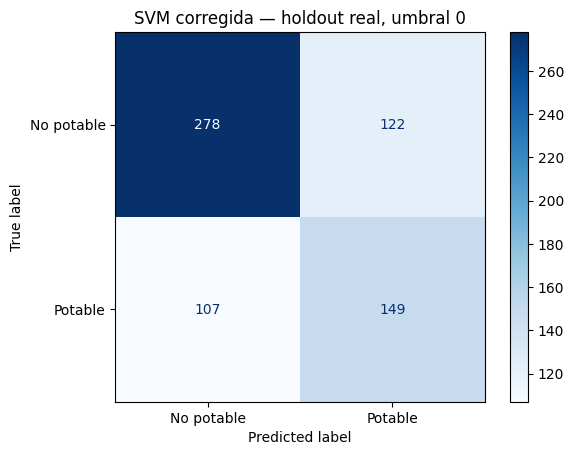

In [5]:
# 4. SVM corregida: todo el preprocesamiento se aprende solo con training
# El test no participa en imputación, escalado, SMOTE ni selección del modelo.
svm_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=SEED)),
    ('svc', SVC(
        kernel='rbf',
        C=SVM_PARAMS['C'],
        gamma=SVM_PARAMS['gamma'],
        cache_size=1500,
    )),
])

svm_pipeline.fit(X_train_raw, y_train)
test_scores = svm_pipeline.decision_function(X_test_raw)
test_pred = (test_scores >= 0.0).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, test_pred, labels=[0, 1]).ravel()
metrics = {
    'accuracy': accuracy_score(y_test, test_pred),
    'precision': precision_score(y_test, test_pred, zero_division=0),
    'recall': recall_score(y_test, test_pred, zero_division=0),
    'f1': f1_score(y_test, test_pred, zero_division=0),
    'specificity': tn / (tn + fp),
    'balanced_accuracy': balanced_accuracy_score(y_test, test_pred),
    'mcc': matthews_corrcoef(y_test, test_pred),
    'average_precision': average_precision_score(y_test, test_scores),
    'roc_auc': roc_auc_score(y_test, test_scores),
    'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
}
metrics_df = pd.DataFrame([metrics])
display(metrics_df.round(4))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_pred,
    labels=[0, 1],
    display_labels=['No potable', 'Potable'],
    cmap='Blues',
)
plt.title('SVM corregida — holdout real, umbral 0')
plt.show()

In [6]:
# 5. Selección de 64 muestras REALES desde el pool de entrenamiento
# No se usa SMOTE para construir este conjunto.
idx_0 = y_train[y_train == 0].sample(n=32, random_state=SUBSET64_SEED).index.to_numpy()
idx_1 = y_train[y_train == 1].sample(n=32, random_state=SUBSET64_SEED).index.to_numpy()
subset_indices = np.concatenate([idx_0, idx_1]).astype(int)
np.random.default_rng(SUBSET64_SEED).shuffle(subset_indices)

X_64_raw = df.loc[subset_indices, FEATURES].copy()
y_64 = df.loc[subset_indices, TARGET].astype(int).copy()

assert Counter(y_64) == Counter({0: 32, 1: 32})
assert set(subset_indices).issubset(set(train_indices))
assert set(subset_indices).isdisjoint(set(test_indices))
assert len(np.unique(subset_indices)) == 64

raw64 = X_64_raw.copy()
raw64.insert(0, 'source_index', subset_indices)
raw64[TARGET] = y_64.to_numpy()

print('64 muestras originales:', raw64.shape)
print('Clases:', dict(sorted(Counter(y_64).items())))
print('Valores faltantes conservados:', int(X_64_raw.isna().sum().sum()))
display(raw64.head())

64 muestras originales: (64, 11)
Clases: {0: 32, 1: 32}
Valores faltantes conservados: 19


,source_index,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
127,127,7.371085,207.716824,24913.837166,9.616330,362.300180,363.168538,11.542662,67.720704,4.412590,0
41,41,5.331940,194.874065,16658.876503,7.993830,316.675162,335.120398,10.180514,59.572714,4.434820,0
3183,3183,7.164478,213.002441,32751.928963,6.292148,NaN,490.933121,12.683767,58.252613,4.998203,1
1619,1619,6.962325,205.183020,35229.077002,5.088710,254.729932,360.058960,13.617560,NaN,4.526768,1
549,549,NaN,164.378433,15908.561870,11.208688,NaN,360.814296,17.239577,60.179119,4.380978,0


In [7]:
# 6. Cuatro folds exteriores fijos: 48 train / 16 validation por fold
# En la etapa SVM–QSVM, el imputador y el scaler se volverán a ajustar dentro de cada fold.
cv64 = StratifiedKFold(n_splits=4, shuffle=True, random_state=FOLDS64_SEED)
fold_assignment = pd.DataFrame({
    'position': np.arange(64, dtype=int),
    'source_index': subset_indices,
    TARGET: y_64.to_numpy(dtype=int),
    'validation_fold': -1,
})

for fold_id, (_, valid_pos) in enumerate(cv64.split(X_64_raw, y_64)):
    fold_assignment.loc[valid_pos, 'validation_fold'] = fold_id

assert (fold_assignment['validation_fold'] >= 0).all()
fold_summary = (
    fold_assignment
    .groupby(['validation_fold', TARGET])
    .size()
    .unstack(fill_value=0)
    .rename(columns={0: 'class_0', 1: 'class_1'})
)
fold_summary['validation_samples'] = fold_summary.sum(axis=1)
fold_summary['training_samples'] = 64 - fold_summary['validation_samples']

assert (fold_summary['class_0'] == 8).all()
assert (fold_summary['class_1'] == 8).all()
assert (fold_summary['validation_samples'] == 16).all()
assert (fold_summary['training_samples'] == 48).all()

display(fold_summary)

Potability,class_0,class_1,validation_samples,training_samples
validation_fold,,,,
0,8,8,16,48
1,8,8,16,48
2,8,8,16,48
3,8,8,16,48


In [8]:
# 7. Exportación y verificaciones de los artefactos
split_assignments = pd.DataFrame({
    'source_index': df.index.astype(int),
    TARGET: df[TARGET].astype(int),
    'split': np.where(df.index.isin(test_indices), 'locked_holdout', 'training_pool'),
})

metrics_df.to_csv(ARTIFACT_DIR / 'corrected_full_svm_metrics.csv', index=False)
split_assignments.to_csv(ARTIFACT_DIR / 'split_assignments.csv', index=False)
raw64.to_csv(ARTIFACT_DIR / 'qsvm_64_raw.csv', index=False)
fold_assignment.to_csv(ARTIFACT_DIR / 'qsvm_64_folds.csv', index=False)
fold_summary.to_csv(ARTIFACT_DIR / 'qsvm_64_fold_summary.csv')
joblib.dump(svm_pipeline, ARTIFACT_DIR / 'corrected_full_svm_pipeline.joblib')

np.savez_compressed(
    ARTIFACT_DIR / 'qsvm_64_bundle.npz',
    X_raw=X_64_raw.to_numpy(dtype=float),
    y=y_64.to_numpy(dtype=int),
    source_index=subset_indices,
    validation_fold=fold_assignment['validation_fold'].to_numpy(dtype=int),
    feature_names=np.asarray(FEATURES),
)

raw64_sha256 = hashlib.sha256((ARTIFACT_DIR / 'qsvm_64_raw.csv').read_bytes()).hexdigest()
folds_sha256 = hashlib.sha256((ARTIFACT_DIR / 'qsvm_64_folds.csv').read_bytes()).hexdigest()

checks = {
    'split_before_preprocessing': True,
    'label_used_for_imputation': False,
    'smote_applied_to_full_dataset': False,
    'smote_scope': 'training_only_inside_full_svm_pipeline',
    'holdout_contains_only_original_rows': True,
    'subset64_source': 'training_pool_only',
    'subset64_contains_synthetic_rows': False,
    'subset64_balanced_32_32': True,
    'subset64_overlap_with_holdout': False,
    'folds': 4,
    'validation_size_per_fold': 16,
    'training_size_per_fold': 48,
    'validation_class_count_per_fold': {'0': 8, '1': 8},
    'future_preprocessing_rule': 'fit imputer and scaler only on the 48 training rows of each outer fold',
}

manifest = {
    'dataset': {
        'path_at_execution': str(DATA_PATH),
        'sha256': dataset_sha256,
        'rows': int(len(df)),
        'features': FEATURES,
        'target': TARGET,
    },
    'split': {
        'holdout_seed': HOLDOUT_SEED,
        'training_rows': int(len(train_indices)),
        'holdout_rows': int(len(test_indices)),
    },
    'corrected_full_svm': {
        'params': SVM_PARAMS,
        'pipeline': ['median_imputer', 'standard_scaler', 'SMOTE_training_only', 'SVC_RBF'],
        'decision_threshold': 0.0,
        'metrics': {k: (int(v) if k in {'tn','fp','fn','tp'} else float(v)) for k, v in metrics.items()},
        'note': 'This full model is a corrected reproduction of the simple Gemini-style experiment; it is not yet the final SVM-QSVM benchmark.',
    },
    'subset64': {
        'selection_seed': SUBSET64_SEED,
        'fold_seed': FOLDS64_SEED,
        'rows': 64,
        'class_counts': {'0': 32, '1': 32},
        'raw_csv_sha256': raw64_sha256,
        'fold_csv_sha256': folds_sha256,
    },
    'checks': checks,
    'environment': {
        'python': platform.python_version(),
        'numpy': np.__version__,
        'pandas': pd.__version__,
        'scikit_learn': sklearn.__version__,
        'imbalanced_learn': imblearn.__version__,
    },
}
with open(ARTIFACT_DIR / 'qsvm_data_manifest.json', 'w', encoding='utf-8') as f:
    json.dump(manifest, f, indent=2, ensure_ascii=False)

check_rows = [{'check': k, 'value': json.dumps(v, ensure_ascii=False)} for k, v in checks.items()]
pd.DataFrame(check_rows).to_csv(ARTIFACT_DIR / 'artifact_checks.csv', index=False)

print('Artefactos generados en:', ARTIFACT_DIR)
for path in sorted(ARTIFACT_DIR.iterdir()):
    print('-', path.name)

Artefactos generados en: /content/drive/MyDrive/Colab Notebooks/artifacts_qsvm_input
- artifact_checks.csv
- corrected_full_svm_metrics.csv
- corrected_full_svm_pipeline.joblib
- qsvm_64_bundle.npz
- qsvm_64_fold_summary.csv
- qsvm_64_folds.csv
- qsvm_64_raw.csv
- qsvm_data_manifest.json
- split_assignments.csv


## Fin de esta etapa

Los artefactos quedan congelados para la próxima fase. No se debe volver a seleccionar otra muestra de 64 ni cambiar sus folds sin documentar una nueva versión del experimento.